# BVA Qudit Analysis

This notebook reads BVA summary logs from `Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs` in read-only mode.
It filters by qudit `dimension`, `LT_comp`, and `date_time`, then reproduces the same style of analysis as the existing BVA notebook.


In [46]:
from pathlib import Path
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

LOG_ROOT = Path(r"Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs")

# User inputs.
dimension = 5
LT_comp = False
date_time = "20260330_2102"

print(f"Using read-only log directory: {LOG_ROOT}")
print(f"dimension = {dimension}")
print(f"LT_comp = {LT_comp}")
print(f"date_time = {date_time}")


def parse_population_line(line):
    line = line.strip()
    if line.startswith('[') and line.endswith(']'):
        line = line[1:-1]
    values = np.fromstring(line, sep=' ')
    return values


def parse_hidden_value(hidden_token):
    token = str(hidden_token).strip()
    if token == "":
        raise ValueError("hidden token is empty")
    try:
        return int(token)
    except ValueError as exc:
        raise ValueError(f"Could not parse hidden value '{token}' as an integer") from exc


def parse_log_filename(path):
    base = Path(path).name
    dim_match = re.search(r"BVA_(\d+)_", base, flags=re.IGNORECASE)
    hidden_match = re.search(r"hiddenval_([^_]+)", base, flags=re.IGNORECASE)
    lt_match = re.search(r"LT_comp_(True|False)", base, flags=re.IGNORECASE)
    dt_matches = re.findall(r"(\d{8}_\d{4,6})", base)

    if dim_match is None or hidden_match is None or not dt_matches:
        return None

    hidden_token = hidden_match.group(1)
    try:
        hidden_value = parse_hidden_value(hidden_token)
    except ValueError:
        return None

    return {
        "filename": base,
        "dimension": int(dim_match.group(1)),
        "hidden_token": hidden_token,
        "hidden_value": hidden_value,
        "lt_comp": None if lt_match is None else (lt_match.group(1) == "True"),
        "date_time": dt_matches[-1],
    }


def load_qudit_bva_logs(log_root, dimension, LT_comp, date_time):
    log_root = Path(log_root)
    if not log_root.exists():
        raise FileNotFoundError(f"Log directory does not exist or is not accessible: {log_root}")

    matched_meta = []
    for path in sorted(log_root.glob("*")):
        if not path.is_file():
            continue
        meta = parse_log_filename(path)
        if meta is None:
            continue
        if meta["dimension"] != int(dimension):
            continue
        if meta["lt_comp"] is None or meta["lt_comp"] != bool(LT_comp):
            continue
        if str(date_time) not in meta["date_time"]:
            continue
        meta["path"] = str(path)
        matched_meta.append(meta)

    if not matched_meta:
        raise FileNotFoundError(
            "No matching BVA log files were found for the requested dimension / LT_comp / date_time filter."
        )

    pop_data = {}
    file_paths = {}
    summary_paths = {}

    for meta in matched_meta:
        path = Path(meta["path"])
        lines = path.read_text(encoding='utf-8').splitlines()
        if len(lines) < 2:
            print(f"Skipping {path.name}: file does not contain enough lines.")
            continue

        pop_vector = parse_population_line(lines[0])
        experiment_path = lines[-1].strip()
        hidden_value = meta["hidden_value"]

        pop_data[hidden_value] = pop_vector
        file_paths[hidden_value] = experiment_path
        summary_paths[hidden_value] = str(path)

    hidden_values = sorted(pop_data.keys())
    if not hidden_values:
        raise ValueError("Matching files were found, but none contained usable population data.")

    return hidden_values, pop_data, file_paths, summary_paths


hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
    LOG_ROOT,
    dimension=dimension,
    LT_comp=LT_comp,
    date_time=date_time,
)

print(f"Matched hidden values: {hidden_values}")
print(f"Matched file count: {len(hidden_values)}")
missing_hidden_values = [value for value in range(dimension) if value not in hidden_values]
print(f"Missing hidden values: {missing_hidden_values}")


Using read-only log directory: Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs
dimension = 5
LT_comp = False
date_time = 20260330_2102
Matched hidden values: [0, 1, 2, 3, 4]
Matched file count: 5
Missing hidden values: []


8.5
10.5
10.5
11.5
11.5


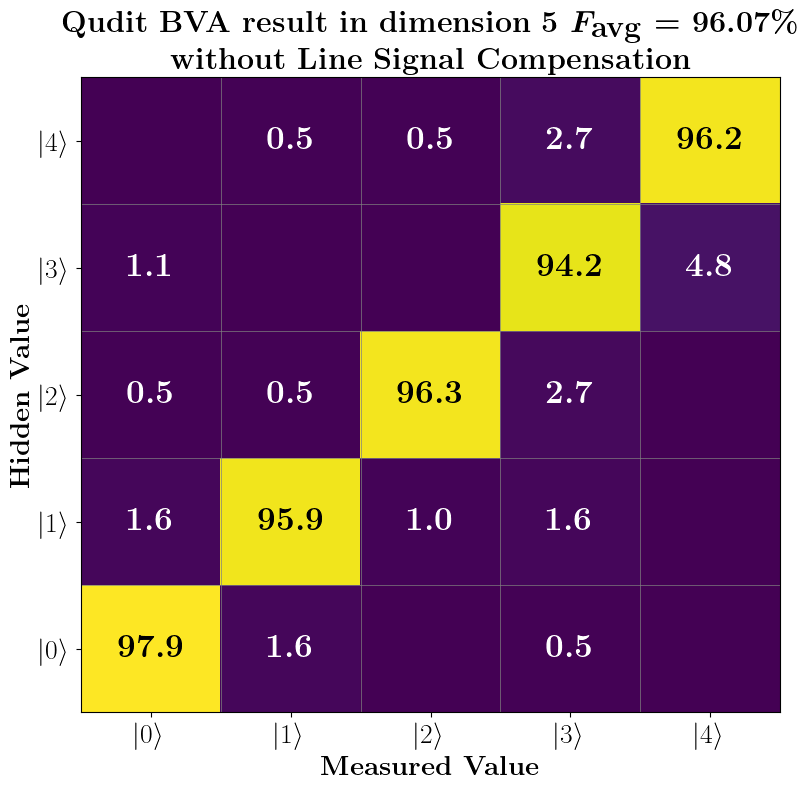

average fidelity = 0.9606751975674916
average detection rate = 0.9399999999999998


In [47]:
def load_experiment_from_file(path):
    exp = []
    with open(path, 'r') as f:
        for line in f:
            exp.append(json.loads(line)[0]["0"])
    return exp


def getShelvingThreshold(counts):
    ds = np.sort(counts, axis=None)
    if len(ds) > 4000:
        ds = ds[2000:]
    if len(ds) > 2000:
        st = round(ds.size / (len(counts) * 0.00150167))
        st = 1 if st < 1 else st
        ds = ds[0:-1:st]
    dsd = ds[1:-1] - ds[0:-2]
    th = max(dsd) / 2 + ds[np.argmax(dsd)]
    hc, be = np.histogram(counts, bins=range(4, 31))
    th = be[np.argmin(hc)] + 0.5
    if th < 2 or th > 20:
        th = 11.5
    return th, ds


keys = hidden_values
n_hidden = len(keys)
ket_avg = [None] * n_hidden
ket_dr = [0.0] * n_hidden
threshold_info = [None] * n_hidden

for row_index, hidden_value in enumerate(keys):
    experiment_path = file_paths[hidden_value]
    experiments = load_experiment_from_file(experiment_path)
    if len(experiments) == 0:
        continue

    experiments = np.asarray(experiments)
    flat_counts = experiments.ravel()
    try:
        threshold, _ = getShelvingThreshold(flat_counts)
        print(threshold)
    except Exception:
        threshold = None

    threshold_info[row_index] = (flat_counts, threshold, hidden_value)
    bright_mask = experiments > threshold
    resolved = np.full(bright_mask.shape, False, dtype=bool)
    for rep_index in range(bright_mask.shape[0]):
        transition_indices = np.where(bright_mask[rep_index])[0]
        if transition_indices.size > 0 and transition_indices[0] != 0:
            resolved[rep_index, transition_indices[0]] = True

    valid_rows = resolved.any(axis=1)
    filtered = resolved[valid_rows]
    ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
    if filtered.shape[0] > 0:
        ket_avg[row_index] = np.mean(filtered, axis=0)

meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
data_m = np.zeros((n_hidden, meas_dim), dtype=float)
for row_index in range(n_hidden):
    if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
        vector = ket_avg[row_index][1:]
        data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

fidelities = []
for row_index, hidden_value in enumerate(keys):
    if hidden_value < meas_dim and ket_avg[row_index] is not None:
        fidelities.append(data_m[row_index, hidden_value])

avg_fid = np.mean(fidelities) if fidelities else np.nan
avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan

fig, ax = plt.subplots(figsize=(max(8, 0.8 * meas_dim), max(8, 0.6 * n_hidden)))
im = ax.imshow(data_m, cmap='viridis', aspect='auto')

hidden_labels = [rf'$|{value}\rangle$' for value in keys]
measured_labels = [rf'$|{value}\rangle$' for value in range(meas_dim)]
ax.set_xticks(np.arange(meas_dim))
ax.set_xticklabels(measured_labels, fontsize=20)
ax.set_yticks(np.arange(n_hidden))
ax.set_yticklabels(hidden_labels, fontsize=20)
ax.invert_yaxis()
ax.set_xlabel(r'\textbf{Measured Value}', fontsize=20)
ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=20)

for row_index in range(n_hidden):
    if ket_avg[row_index] is None:
        ax.text(meas_dim / 2, row_index, r'\textbf{No Valid Data}', ha='center', va='center', color='red', fontsize=14)
    else:
        for col_index in range(meas_dim):
            if data_m[row_index, col_index] > 0.005:
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{data_m[row_index, col_index] * 100:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if data_m[row_index, col_index] > 0.5 else 'white',
                    fontsize=24,
                )

for x in np.arange(-0.5, meas_dim, 1):
    ax.axvline(x, color='gray', linewidth=0.5)
for y in np.arange(-0.5, n_hidden, 1):
    ax.axhline(y, color='gray', linewidth=0.5)

line_label = r'\textbf{with Line Signal Compensation}' if LT_comp else r'\textbf{without Line Signal Compensation}'
ax.set_title(
    rf'\textbf{{Qudit BVA result in dimension {dimension} }}' +
    r'\boldmath$F_{\textbf{avg}}$' +
    rf'\textbf{{ = {100.0 * avg_fid:.2f}\%}}' + '\n' + line_label,
    fontsize=22,
)
plt.tight_layout()
plt.show()

print(f"average fidelity = {avg_fid}")
print(f"average detection rate = {avg_detection_rate}")


In [48]:
print(avg_fid)


0.9606751975674916


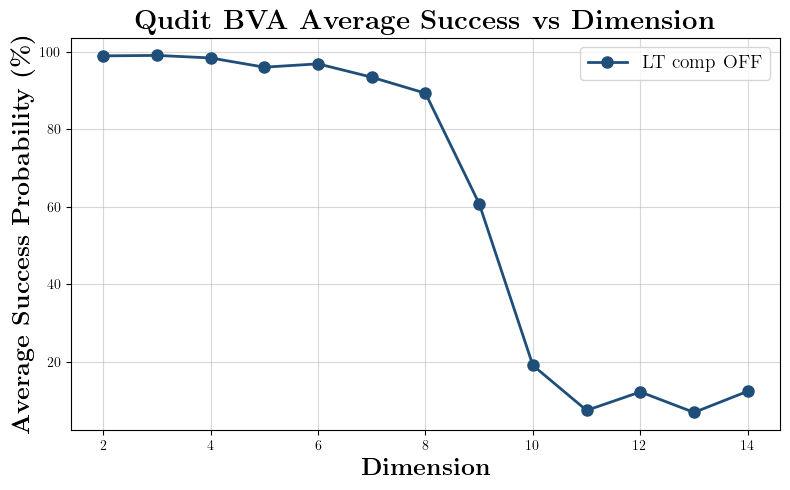

dimensions_by_lt = {False: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], True: []}
avg_success_probability_by_lt = {False: [0.9898872300598092, 0.991087140124243, 0.9845217675551687, 0.9606751975674916, 0.9692662983594058, 0.9348141608455924, 0.8933845406545248, 0.6082492264543031, 0.19069867503950472, 0.07453552165081936, 0.12227496773848999, 0.06929236852542099, 0.12400063257354135], True: []}

LT_comp = False
  d= 2, date_time=20260330_2008, avg_success_probability=98.99%, missing_hidden_values=[]
  d= 3, date_time=20260330_2017, avg_success_probability=99.11%, missing_hidden_values=[]
  d= 4, date_time=20260330_2017, avg_success_probability=98.45%, missing_hidden_values=[]
  d= 5, date_time=20260330_2102, avg_success_probability=96.07%, missing_hidden_values=[]
  d= 6, date_time=20260330_2131, avg_success_probability=96.93%, missing_hidden_values=[]
  d= 7, date_time=20260330_2208, avg_success_probability=93.48%, missing_hidden_values=[]
  d= 8, date_time=20260331_0954, avg_success

In [51]:
# Batch analysis configuration.
# Fill in the dimensions and date_time strings you want to compare.
# The structure is: LT_comp -> {dimension: date_time}
batch_cases = {
    False: {
        2: "20260330_2008",
        3: "20260330_2017",
        4: "20260330_2017",
        5: "20260330_2102",
        6: "20260330_2131",
        7: "20260330_2208",
        8: "20260331_0954",
        9: "20260331_0954",
        10: "20260331_0954",
        11: "20260331_0954",
        12: "20260331_0954",
        13: "20260401_1032",
        14: "20260401_1032",
    },
    True: {
        # 2: "20260330_2015",
    },
}


def analyze_qudit_bva_case(dimension, LT_comp, date_time, log_root=LOG_ROOT):
    hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
        log_root,
        dimension=dimension,
        LT_comp=LT_comp,
        date_time=date_time,
    )

    keys = hidden_values
    n_hidden = len(keys)
    ket_avg = [None] * n_hidden
    ket_dr = [0.0] * n_hidden

    for row_index, hidden_value in enumerate(keys):
        experiment_path = file_paths[hidden_value]
        experiments = load_experiment_from_file(experiment_path)
        if len(experiments) == 0:
            continue

        experiments = np.asarray(experiments)
        flat_counts = experiments.ravel()
        try:
            threshold, _ = getShelvingThreshold(flat_counts)
        except Exception:
            threshold = None

        bright_mask = experiments > threshold
        resolved = np.full(bright_mask.shape, False, dtype=bool)
        for rep_index in range(bright_mask.shape[0]):
            transition_indices = np.where(bright_mask[rep_index])[0]
            if transition_indices.size > 0 and transition_indices[0] != 0:
                resolved[rep_index, transition_indices[0]] = True

        valid_rows = resolved.any(axis=1)
        filtered = resolved[valid_rows]
        ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
        if filtered.shape[0] > 0:
            ket_avg[row_index] = np.mean(filtered, axis=0)

    meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
    data_m = np.zeros((n_hidden, meas_dim), dtype=float)
    for row_index in range(n_hidden):
        if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
            vector = ket_avg[row_index][1:]
            data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

    success_probabilities = []
    for row_index, hidden_value in enumerate(keys):
        if hidden_value < meas_dim and ket_avg[row_index] is not None:
            success_probabilities.append(data_m[row_index, hidden_value])

    avg_success_probability = np.mean(success_probabilities) if success_probabilities else np.nan
    avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan
    missing_hidden_values = [value for value in range(dimension) if value not in keys]

    return {
        'dimension': int(dimension),
        'LT_comp': bool(LT_comp),
        'date_time': str(date_time),
        'hidden_values': list(keys),
        'missing_hidden_values': missing_hidden_values,
        'data_m': data_m,
        'avg_success_probability': float(avg_success_probability),
        'avg_detection_rate': float(avg_detection_rate),
        'success_probabilities': np.asarray(success_probabilities, dtype=float),
        'summary_paths': dict(summary_paths),
        'experiment_paths': dict(file_paths),
    }


batch_results = {False: [], True: []}
dimensions_by_lt = {False: [], True: []}
avg_success_probability_by_lt = {False: [], True: []}

for lt_value in [False, True]:
    dim_to_datetime = batch_cases.get(lt_value, {})
    for dim_value, dt_value in sorted(dim_to_datetime.items()):
        result = analyze_qudit_bva_case(
            dimension=dim_value,
            LT_comp=lt_value,
            date_time=dt_value,
            log_root=LOG_ROOT,
        )
        batch_results[lt_value].append(result)
        dimensions_by_lt[lt_value].append(int(dim_value))
        avg_success_probability_by_lt[lt_value].append(result['avg_success_probability'])

fig, ax = plt.subplots(figsize=(8, 5))
plot_styles = {
    False: {'label': 'LT comp OFF', 'color': '#1f4e79', 'marker': 'o'},
    True: {'label': 'LT comp ON', 'color': '#c05621', 'marker': 's'},
}

for lt_value in [False, True]:
    dims = dimensions_by_lt[lt_value]
    avg_success = avg_success_probability_by_lt[lt_value]
    if len(dims) == 0:
        continue
    style = plot_styles[lt_value]
    ax.plot(
        dims,
        100.0 * np.asarray(avg_success, dtype=float),
        marker=style['marker'],
        markersize=8,
        linewidth=2,
        color=style['color'],
        label=style['label'],
    )

ax.set_xlabel(r'\textbf{Dimension}', fontsize=18)
ax.set_ylabel(r'\textbf{Average Success Probability (\%)}', fontsize=18)
ax.set_title(r'\textbf{Qudit BVA Average Success vs Dimension}', fontsize=20)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

print('dimensions_by_lt =', dimensions_by_lt)
print('avg_success_probability_by_lt =', avg_success_probability_by_lt)

for lt_value in [False, True]:
    print(f"\nLT_comp = {lt_value}")
    for result in batch_results[lt_value]:
        print(
            f"  d={result['dimension']:2d}, date_time={result['date_time']}, "
            f"avg_success_probability={100.0 * result['avg_success_probability']:.2f}%, "
            f"missing_hidden_values={result['missing_hidden_values']}"
        )


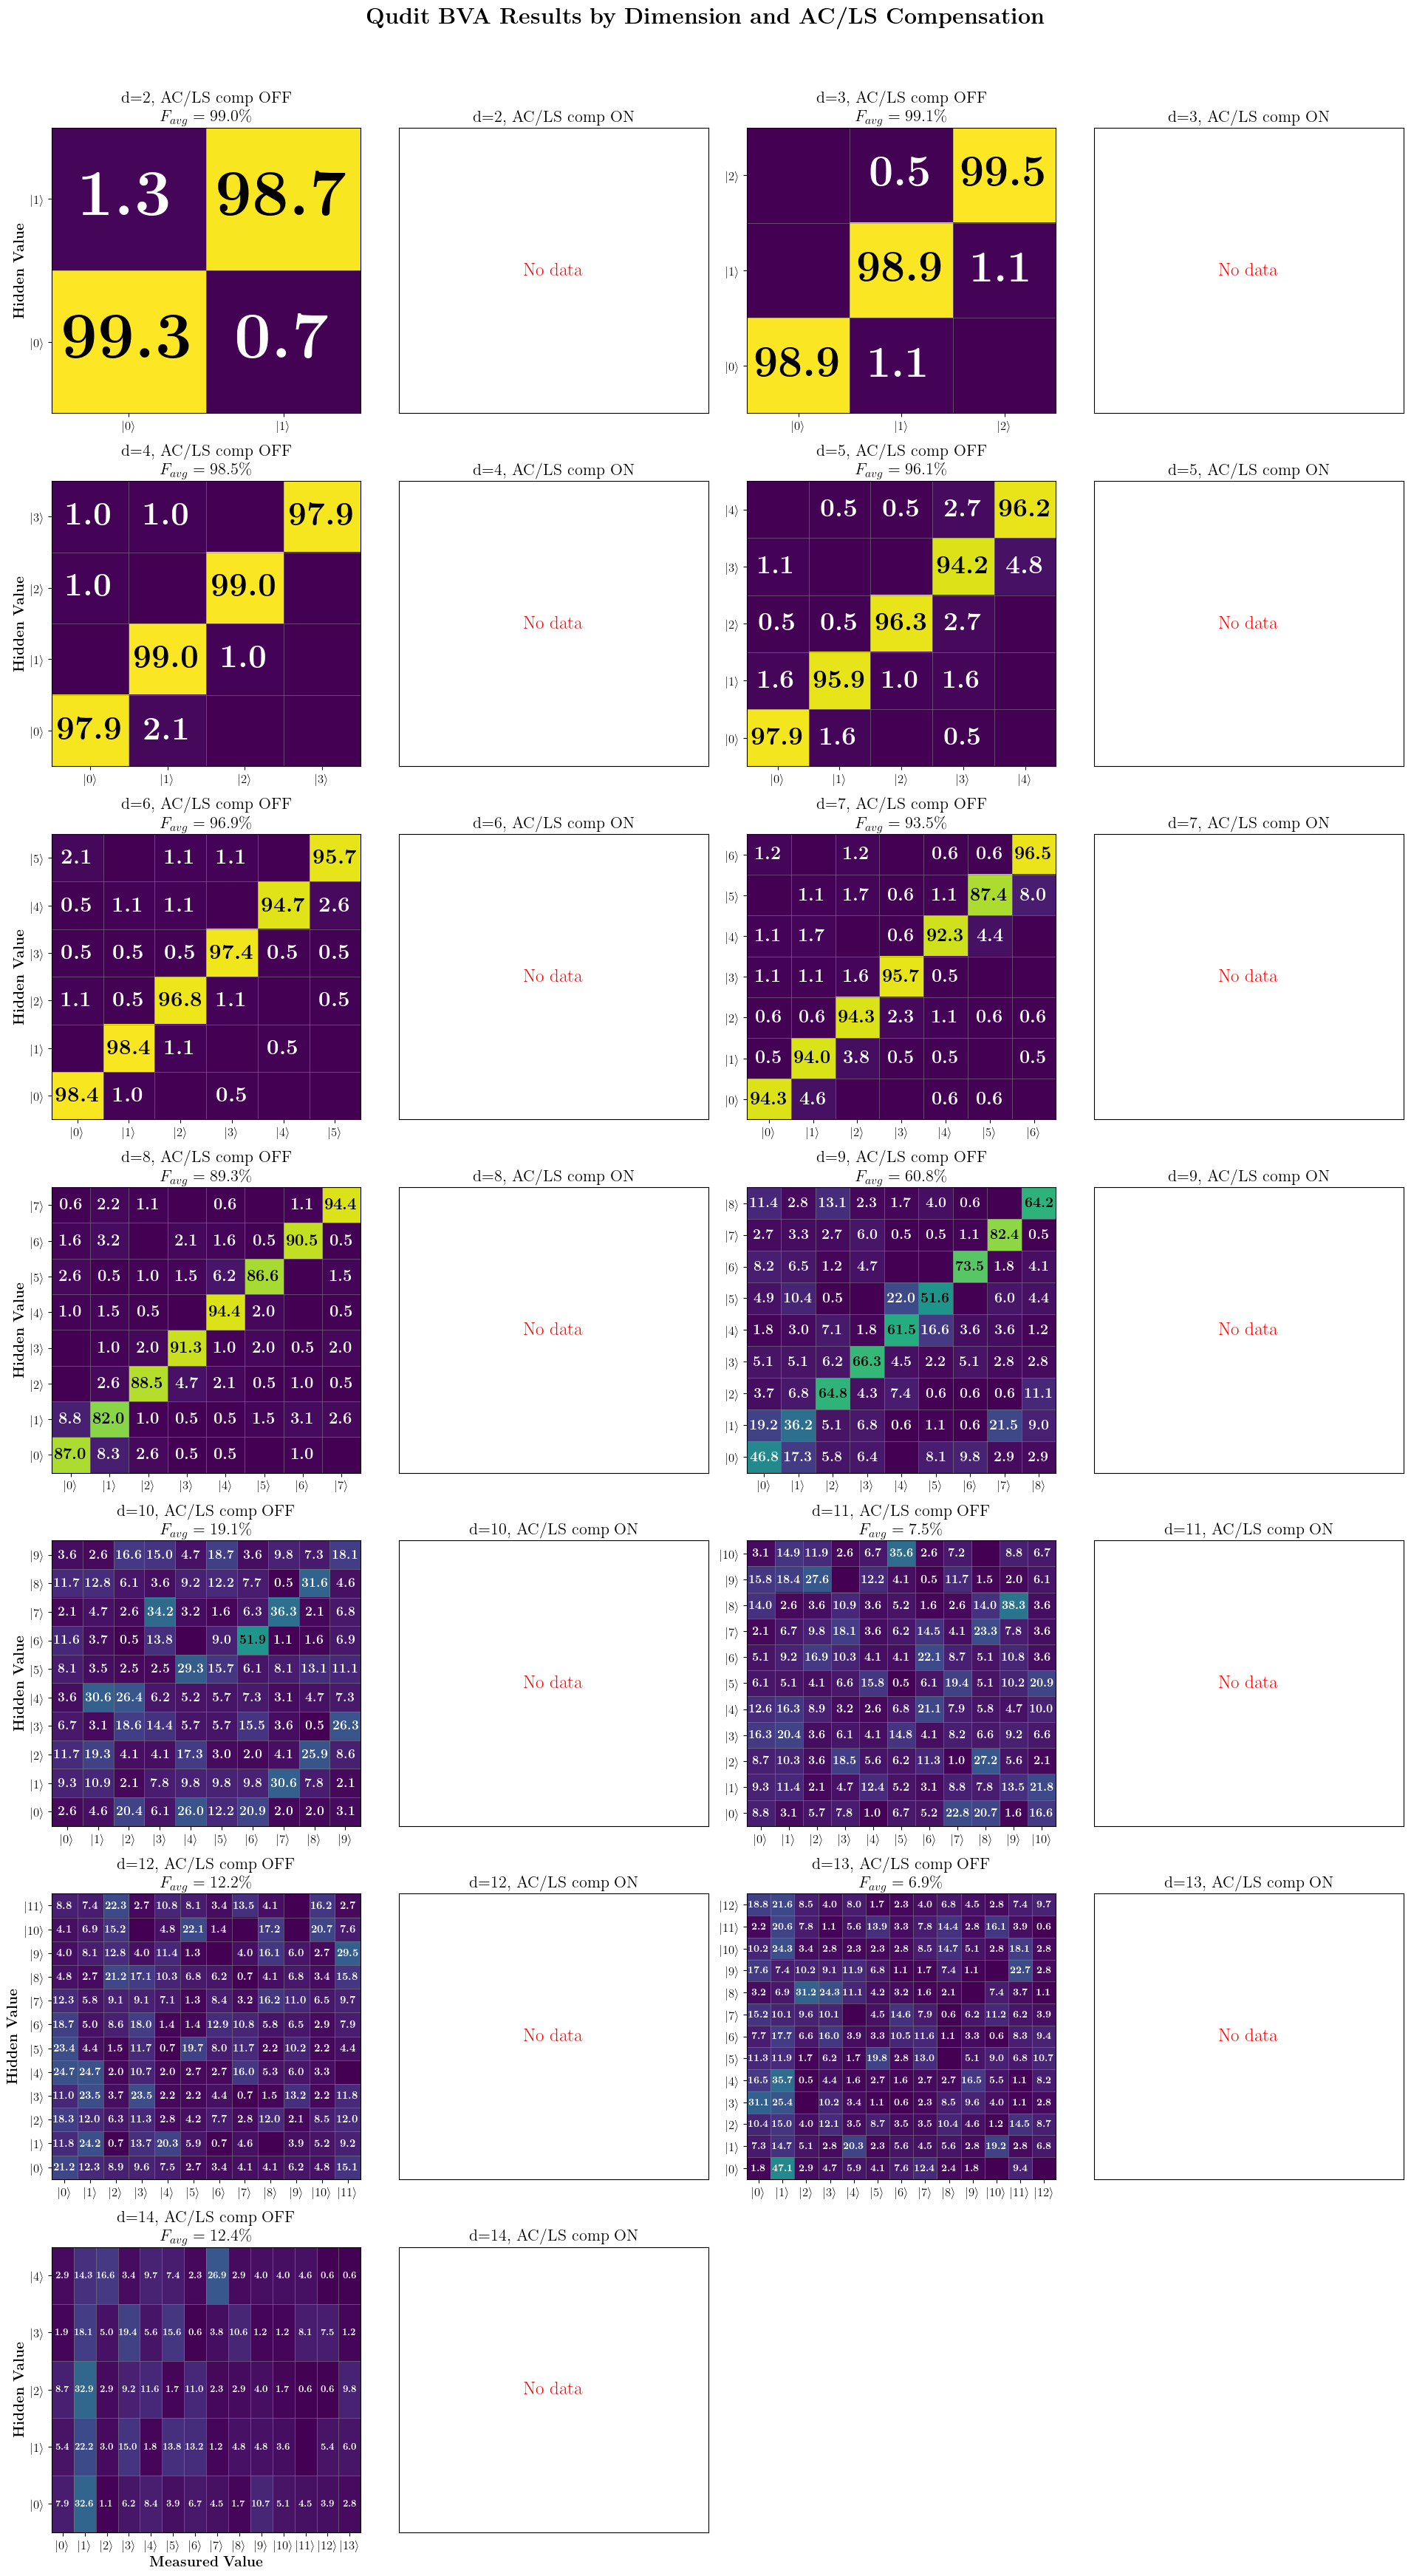

In [52]:
from math import ceil

# Heatmap grid for all analyzed dimensions.
# Layout: 4 columns total, arranged as
# [d1 False, d1 True, d2 False, d2 True] on each row.

result_lookup = {False: {}, True: {}}
for lt_value in [False, True]:
    for result in batch_results[lt_value]:
        result_lookup[lt_value][result['dimension']] = result

all_dimensions = sorted(set(dimensions_by_lt[False]) | set(dimensions_by_lt[True]))
if len(all_dimensions) == 0:
    raise ValueError('No batch analysis results are available to plot.')

pairs_per_row = 2
n_rows = ceil(len(all_dimensions) / pairs_per_row)
n_cols = 4

available_matrices = [
    np.asarray(result_lookup[lt_value][dim_value]['data_m'], dtype=float)
    for dim_value in all_dimensions
    for lt_value in [False, True]
    if dim_value in result_lookup[lt_value]
]
vmax = max(np.max(matrix) for matrix in available_matrices) if available_matrices else 1.0
vmax = max(float(vmax), 1e-6)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, max(4.5, 5.0 * n_rows)),
    squeeze=False,
)

for ax in axes.ravel():
    ax.axis('off')

for dim_index, dim_value in enumerate(all_dimensions):
    row = dim_index // pairs_per_row
    pair_offset = dim_index % pairs_per_row
    base_col = 2 * pair_offset

    for lt_offset, lt_value in enumerate([False, True]):
        ax = axes[row, base_col + lt_offset]
        ax.axis('on')

        result = result_lookup[lt_value].get(dim_value)
        lt_label = 'AC/LS comp ON' if lt_value else 'AC/LS comp OFF'

        if result is None:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'd={dim_value}, {lt_label}', fontsize=16)
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=18, color='red', transform=ax.transAxes)
            continue

        data_m = np.asarray(result['data_m'], dtype=float)
        im = ax.imshow(data_m, cmap='viridis', aspect='auto', vmin=0.0, vmax=vmax)

        hidden_values = result['hidden_values']
        measured_dim = data_m.shape[1]
        hidden_labels = [rf'$|{value}\rangle$' for value in hidden_values]
        measured_labels = [rf'$|{value}\rangle$' for value in range(measured_dim)]

        ax.set_xticks(np.arange(measured_dim))
        ax.set_xticklabels(measured_labels, fontsize=12)
        ax.set_yticks(np.arange(len(hidden_values)))
        ax.set_yticklabels(hidden_labels, fontsize=12)
        ax.invert_yaxis()
        ax.set_title(
            f'd={dim_value}, {lt_label}\n' + rf'$F_{{avg}} = {100.0 * result["avg_success_probability"]:.1f}\%$',
            fontsize=16,
        )

        if base_col == 0 and lt_offset == 0:
            ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=14)
        else:
            ax.set_ylabel('')

        if row == n_rows - 1:
            ax.set_xlabel(r'\textbf{Measured Value}', fontsize=14)

        for x in np.arange(-0.5, measured_dim, 1):
            ax.axvline(x, color='gray', linewidth=0.4)
        for y in np.arange(-0.5, len(hidden_values), 1):
            ax.axhline(y, color='gray', linewidth=0.4)

        for row_index in range(data_m.shape[0]):
            for col_index in range(data_m.shape[1]):
                value = data_m[row_index, col_index]
                if value <= 0.005:
                    continue
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{100.0 * value:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if value > 0.5 else 'white',
                    fontsize=128/dim_value,
                    fontweight='bold',
                )

for row in range(n_rows):
    for col in range(n_cols):
        if not axes[row, col].has_data() and len(axes[row, col].texts) == 0:
            axes[row, col].axis('off')

fig.suptitle(r'\textbf{Qudit BVA Results by Dimension and AC/LS Compensation}', fontsize=22, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
